Loading of data-Dreaddit Dataset and Symspell Dictionary to correct spelling error

In [3]:
import gdown
files = {
    "dreaddit-test.csv": "1EcpLYZLbhWlLbdffscsPu7CePOjveMow",
    "dreaddit-train.csv": "1K0KgG1Cx8BDKZ4i_OrFWKYh4Cr0GHEju",
    "frequency_dictionary_en_82_765.txt": "1ck6TRenvXQpsfw5ItCqViJle4mhXJQxG"
}

for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1EcpLYZLbhWlLbdffscsPu7CePOjveMow
To: /content/dreaddit-test.csv
100%|██████████| 759k/759k [00:00<00:00, 8.46MB/s]
Downloading...
From: https://drive.google.com/uc?id=1K0KgG1Cx8BDKZ4i_OrFWKYh4Cr0GHEju
To: /content/dreaddit-train.csv
100%|██████████| 2.72M/2.72M [00:00<00:00, 18.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ck6TRenvXQpsfw5ItCqViJle4mhXJQxG
To: /content/frequency_dictionary_en_82_765.txt
100%|██████████| 1.33M/1.33M [00:00<00:00, 9.99MB/s]


# Data Preprocessing

In [4]:
# Set seed
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [5]:
!pip install symspellpy
from symspellpy.symspellpy import SymSpell, Verbosity

sym_spell = SymSpell(2, 7)

dictionary_path = "frequency_dictionary_en_82_765.txt"
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)


True

Defining function to clean spelling error,skips tokens with length ≤ 3 (to preserve abbreviations like omg)

In [6]:
import re
from symspellpy.symspellpy import Verbosity

def clean_text(text, sym_spell):
    if not isinstance(text, str):
        return text

    # Fix encoding artifacts
    replacements = {
        "â€™": "'",
        "â€œ": '"',
        "â€": '"',
        "â€˜": "'",
        "â€“": "-",
        "â€”": "-",
        "â€¦": "..."
    }

    for bad, good in replacements.items():
        text = text.replace(bad, good)

    tokens = re.findall(r"\b\w+\b|\S", text)
    cleaned_tokens = []

    for token in tokens:
        if len(token) <= 3: ## some short forms like omg might have meanings
            cleaned_tokens.append(token)
            continue

        suggestions = sym_spell.lookup(
            token.lower(),
            Verbosity.CLOSEST,
            max_edit_distance=2
        )

        cleaned_tokens.append(
            suggestions[0].term if suggestions else token
        )

    return " ".join(cleaned_tokens)

In [7]:
##check
sample = "Iâ€™m strsesed becase my exam is tomorow"
print(clean_text(sample, sym_spell))


I ' m stressed because my exam is tomorrow


In [8]:
import pandas as pd
df_train = pd.read_csv('dreaddit-train.csv',encoding="utf-8")
print(df_train.head())

          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text     id  label  \
0  He said he had not felt that way before, sugge...  33181      1   
1  Hey there r/assistance, Not sure if this is th...   2606      0   
2  My mom then hit me with the newspaper and it s...  38816      1   
3  until i met my new boyfriend, he is amazing, h...    239      1   
4  October is Domestic Violence Awareness Month a...   1421      1   

   confidence  social_timestamp  social_karma  syntax_ari  ...  \
0         0.8        1521614353             5    1.806818  ...   
1         1.0        1527009817             4    9.429737  ...   
2         0.8        1535935605             2    7.769821  ...   
3         0.6        1516429555       

In [9]:
df_train["text_cleaned"] = df_train["text"].apply(
    lambda x: clean_text(x, sym_spell)
)

# Visualisation

A comparison of stress post rates across subreddits shows that:anxiety has one of the highest stress post rates, domesticviolence also ranks at the top. This result is expected, as both communities focus on mental health struggles, personal distress and emotional or traumatic experience

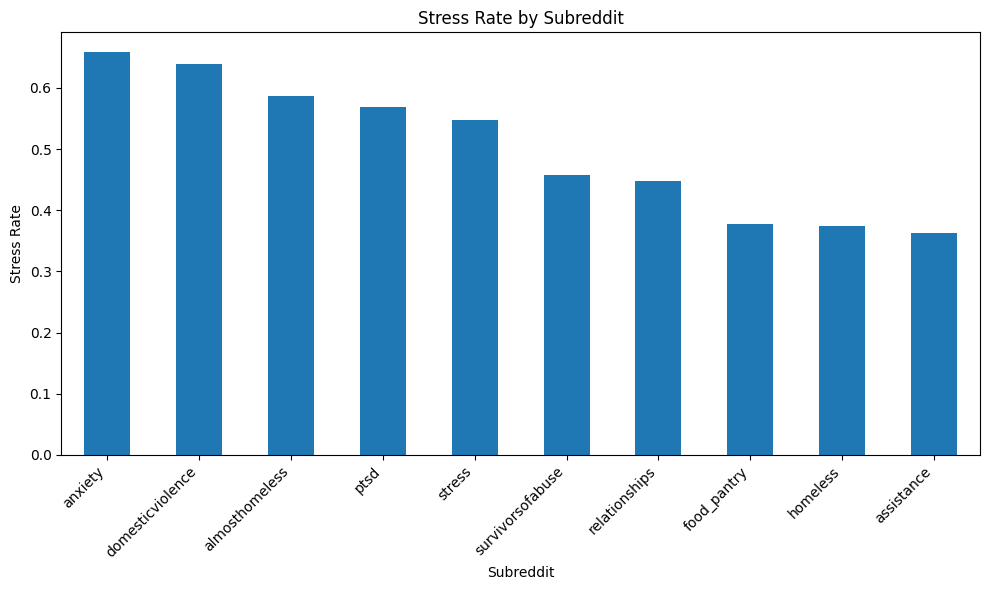

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

stress_rate = (
    df_train.groupby("subreddit")["label"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
stress_rate.plot(kind="bar")
plt.ylabel("Stress Rate")
plt.xlabel("Subreddit")
plt.title("Stress Rate by Subreddit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## subreddit may be an important feature to include


In [11]:
import seaborn as sns
import pandas as pd

df_train['timestamp_dt'] = pd.to_datetime(df_train['social_timestamp'], unit='s')
df_train['hour'] = df_train['timestamp_dt'].dt.hour
df_train['day'] = df_train['timestamp_dt'].dt.day
df_train['month'] = df_train['timestamp_dt'].dt.month
df_train['weekday'] = df_train['timestamp_dt'].dt.day_name()

print(df_train[['social_timestamp', 'timestamp_dt', 'hour', 'weekday']].head())



   social_timestamp        timestamp_dt  hour    weekday
0        1521614353 2018-03-21 06:39:13     6  Wednesday
1        1527009817 2018-05-22 17:23:37    17    Tuesday
2        1535935605 2018-09-03 00:46:45     0     Monday
3        1516429555 2018-01-20 06:25:55     6   Saturday
4        1539809005 2018-10-17 20:43:25    20  Wednesday


To examine whether posting time shows any pattern, stress posts were grouped by hour of the day and converted into percentages. I found that the percentage of stress-related posts is higher in the morning hours.

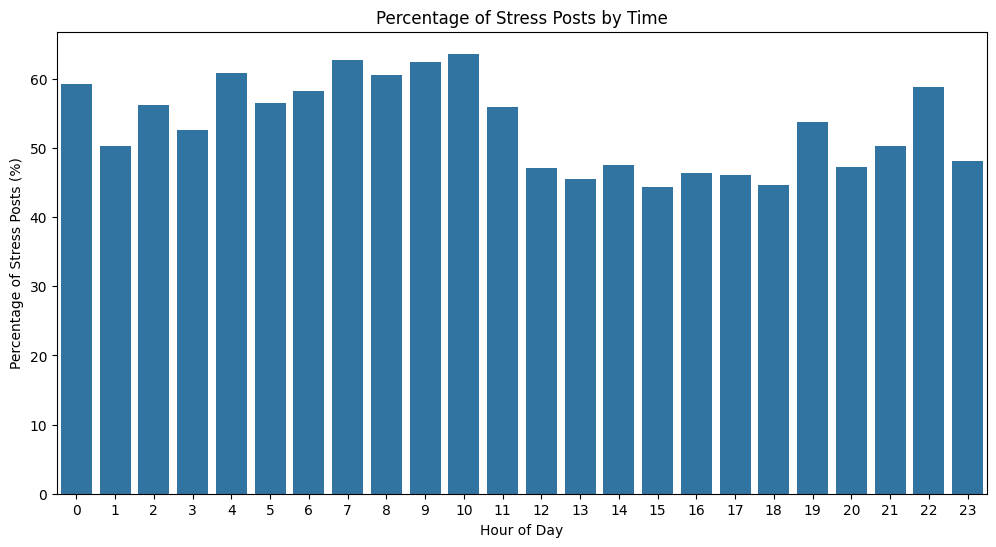

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train['is_stress'] = df_train['label']  # 1 for stress, 0 for non-stress

hourly_stats = df_train.groupby('hour')['is_stress'].mean() * 100
hourly_stats = hourly_stats.reset_index()
hourly_stats.rename(columns={'is_stress': 'stress_percentage'}, inplace=True)

plt.figure(figsize=(12,6))
sns.barplot(x='hour', y='stress_percentage', data=hourly_stats)
plt.title('Percentage of Stress Posts by Time')
plt.xlabel('Hour of Day')
plt.ylabel('Percentage of Stress Posts (%)')
plt.xticks(range(0,24))
plt.show()

## higher percentage of stressed post in the morning


To assess whether class imbalance could affect model performance, the distribution of stress vs. non-stress labels was examined.

Stress: 52.4%
Non-stress: 47.6%

The classes are fairly balanced, with only a ~4.8% difference between them thus does not require imbalance correction techniques.

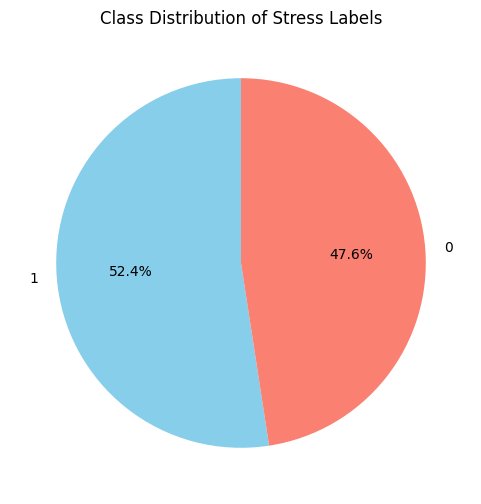

In [13]:
import matplotlib.pyplot as plt

label_counts = df_train['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','salmon'])
plt.title('Class Distribution of Stress Labels')
plt.show()

## considered quite balanced


In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score


#Train test split

In [15]:
X = df_train.drop(columns=["label","confidence","post_id","sentence_range","id","social_timestamp","timestamp_dt","month","day"])
y = df_train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train["text_cleaned"].head())
print(y_train.head())


1314    We get no child support and are doing well fin...
654     & # x200B ; Hey everyone , being that hurrican...
898     woke up 4 days later , incubated and paralysed...
2519    I ’ m also quite intellectual , I can speak 2 ...
1982    I don ' t need that . this sucks but is far fr...
Name: text_cleaned, dtype: object
1314    1
654     1
898     0
2519    1
1982    1
Name: label, dtype: int64


#  Model Selection

The first candidate model uses:

TF-IDF vectorization to convert text into numerical features which down-weights very common words, and preserve meaningful signal

Ridge Regression (L2 regularization) as the classifier to reduce dimensions

In [16]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ["subreddit","weekday"]
text_col = "text_cleaned"
numeric_cols = [
    "hour",
    "social_karma",
    "syntax_ari",
    "lex_liwc_WC",
    "lex_liwc_Analytic",
    "lex_liwc_Clout",
    "lex_liwc_Authentic",
    "lex_liwc_Tone",
    "lex_liwc_WPS",
    "lex_liwc_Sixltr",
    "lex_liwc_Dic",
    "lex_liwc_function",
    "lex_liwc_pronoun",
    "lex_liwc_ppron",
    "lex_liwc_i",
    "lex_liwc_we",
    "lex_liwc_you",
    "lex_liwc_shehe",
    "lex_liwc_they",
    "lex_liwc_ipron",
    "lex_liwc_article",
    "lex_liwc_prep",
    "lex_liwc_auxverb",
    "lex_liwc_adverb",
    "lex_liwc_conj",
    "lex_liwc_negate",
    "lex_liwc_verb",
    "lex_liwc_adj",
    "lex_liwc_compare",
    "lex_liwc_interrog",
    "lex_liwc_number",
    "lex_liwc_quant",
    "lex_liwc_affect",
    "lex_liwc_posemo",
    "lex_liwc_negemo",
    "lex_liwc_anx",
    "lex_liwc_anger",
    "lex_liwc_sad",
    "lex_liwc_social",
    "lex_liwc_family",
    "lex_liwc_friend",
    "lex_liwc_female",
    "lex_liwc_male",
    "lex_liwc_cogproc",
    "lex_liwc_insight",
    "lex_liwc_cause",
    "lex_liwc_discrep",
    "lex_liwc_tentat",
    "lex_liwc_certain",
    "lex_liwc_differ",
    "lex_liwc_percept",
    "lex_liwc_see",
    "lex_liwc_hear",
    "lex_liwc_feel",
    "lex_liwc_bio",
    "lex_liwc_body",
    "lex_liwc_health",
    "lex_liwc_sexual",
    "lex_liwc_ingest",
    "lex_liwc_drives",
    "lex_liwc_affiliation",
    "lex_liwc_achieve",
    "lex_liwc_power",
    "lex_liwc_reward",
    "lex_liwc_risk",
    "lex_liwc_focuspast",
    "lex_liwc_focuspresent",
    "lex_liwc_focusfuture",
    "lex_liwc_relativ",
    "lex_liwc_motion",
    "lex_liwc_space",
    "lex_liwc_time",
    "lex_liwc_work",
    "lex_liwc_leisure",
    "lex_liwc_home",
    "lex_liwc_money",
    "lex_liwc_relig",
    "lex_liwc_death",
    "lex_liwc_informal",
    "lex_liwc_swear",
    "lex_liwc_netspeak",
    "lex_liwc_assent",
    "lex_liwc_nonflu",
    "lex_liwc_filler",
    "lex_liwc_AllPunc",
    "lex_liwc_Period",
    "lex_liwc_Comma",
    "lex_liwc_Colon",
    "lex_liwc_SemiC",
    "lex_liwc_QMark",
    "lex_liwc_Exclam",
    "lex_liwc_Dash",
    "lex_liwc_Quote",
    "lex_liwc_Apostro",
    "lex_liwc_Parenth",
    "lex_liwc_OtherP",
    "lex_dal_max_pleasantness",
    "lex_dal_max_activation",
    "lex_dal_max_imagery",
    "lex_dal_min_pleasantness",
    "lex_dal_min_activation",
    "lex_dal_min_imagery",
    "lex_dal_avg_activation",
    "lex_dal_avg_imagery",
    "lex_dal_avg_pleasantness",
    "social_upvote_ratio",
    "social_num_comments",
    "syntax_fk_grade",
    "sentiment"
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.9
            ),
            text_col
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

In [18]:
##too many features with tf-idf, reduce dimension
l1_selector_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000
)

l1_selector_model.fit(X_train_processed, y_train)
selector = SelectFromModel(
    l1_selector_model,
    prefit=True
)

X_train_selected = selector.transform(X_train_processed)
X_val_selected = selector.transform(X_val_processed)

print("Original feature space:", X_train_processed.shape)
print("Selected feature space:", X_train_selected.shape)

Original feature space: (2270, 3039)
Selected feature space: (2270, 153)


In [19]:
final_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000
)

final_model.fit(X_train_selected, y_train)


LogisticRegression(max_iter=1000, solver='liblinear')

In [20]:
y_val_pred = final_model.predict(X_val_selected)
f1 = f1_score(y_val, y_val_pred)

print("Validation F1-score:", f1)


Validation F1-score: 0.7886855241264559


Second candidate model is BERT

In [21]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

token_lengths = [len(tokenizer.encode(str(text), add_special_tokens=True)) for text in X_train["text_cleaned"]]

print("Maximum token length:", max(token_lengths))
print("Median token length:", int(np.median(token_lengths)))
print("90th percentile length:", int(np.percentile(token_lengths, 90)))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Maximum token length: 378
Median token length: 101
90th percentile length: 155


In [22]:
from torch.utils.data import Dataset
import torch

max_length = 256  # avoid truncation for most posts

class RedditDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = int(self.labels.iloc[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }


In [23]:
train_dataset = RedditDataset(X_train["text_cleaned"], y_train, tokenizer, max_length)
val_dataset = RedditDataset(X_val["text_cleaned"], y_val, tokenizer, max_length)

In [24]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [25]:
from transformers import BertForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") ##use GPU

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2  # stressed vs non-stressed
)

model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
from sklearn.metrics import f1_score

def evaluate_f1(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return f1_score(all_labels, all_preds)




In [27]:
from sklearn.metrics import f1_score
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask
        )

        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()

    # Evaluate once per epoch
    val_f1 = evaluate_f1(model, val_loader, device)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

Epoch 1/3 - Train Loss: 0.5219 | Val F1: 0.8350
Epoch 2/3 - Train Loss: 0.2939 | Val F1: 0.8322
Epoch 3/3 - Train Loss: 0.1571 | Val F1: 0.8384


Third candidate model is random forest

In [28]:
## Try random forest

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)



In [29]:
from sklearn.metrics import f1_score

rf_pipeline.fit(X_train, y_train)

y_val_pred = rf_pipeline.predict(X_val)
rf_f1 = f1_score(y_val, y_val_pred)

print("Random Forest Validation F1:", rf_f1)

Random Forest Validation F1: 0.7759197324414716


Fourth candidate model is BERT with numerical and categorical features, as it is shown in data exploration that subreddit might be associated with stress rates, LIWC features are also considered in this model

In [30]:
## try bert with numeric and categorical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_val_num = scaler.transform(X_val[numeric_cols])

In [31]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

train_enc = tokenize(X_train["text_cleaned"].tolist())
val_enc = tokenize(X_val["text_cleaned"].tolist())

In [32]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])

# combine with numeric features
import numpy as np
X_train_combined = np.hstack([X_train_num, X_train_cat])
X_val_combined = np.hstack([X_val_num, X_val_cat])

import torch
X_train_combined = torch.tensor(X_train_combined, dtype=torch.float)
X_val_combined = torch.tensor(X_val_combined, dtype=torch.float)

In [33]:
import torch
from torch.utils.data import Dataset

class HybridDataset(Dataset):
    def __init__(self, encodings, combined_feats, labels):
        self.encodings = encodings
        self.combined_feats = torch.tensor(combined_feats, dtype=torch.float)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["numeric_feats"] = self.combined_feats[idx]  # renamed for consistency
        item["labels"] = self.labels[idx]
        return item

train_dataset_bert2 = HybridDataset(train_enc, X_train_combined, y_train)
val_dataset_bert2 = HybridDataset(val_enc, X_val_combined, y_val)

/tmp/ipython-input-1633258206.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.combined_feats = torch.tensor(combined_feats, dtype=torch.float)


In [34]:
from torch.utils.data import DataLoader

train_loader_bert2 = DataLoader(train_dataset_bert2, batch_size=16, shuffle=True)
val_loader_bert2 = DataLoader(val_dataset_bert2, batch_size=16)

In [35]:
import torch.nn as nn
from transformers import BertModel

class BertWithFeatures(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.classifier = nn.Sequential(
            nn.Linear(768 + num_numeric_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, numeric_feats):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_emb = outputs.last_hidden_state[:, 0, :]

        combined = torch.cat((cls_emb, numeric_feats), dim=1)
        return self.classifier(combined)

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertWithFeatures(X_train_combined.shape[1]).to(device)

from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
def evaluate_f1_bert2(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            numeric_feats = batch["numeric_feats"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, numeric_feats)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return f1_score(all_labels, all_preds)

In [38]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader_bert2:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        numeric_feats = batch["numeric_feats"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask, numeric_feats)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_f1 = evaluate_f1_bert2(model, val_loader_bert2, device)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {total_loss/len(train_loader):.4f} | "
        f"Val F1: {val_f1:.4f}"
    )


Epoch 1/3 | Train Loss: 0.5069 | Val F1: 0.8083
Epoch 2/3 | Train Loss: 0.3255 | Val F1: 0.8171
Epoch 3/3 | Train Loss: 0.1448 | Val F1: 0.7869


Comparing the 4 models, the pure BERT model achieved the best performance in F1-score.
Although subreddit and temporal features showed associations, adding structured features did not outperform pure BERT possibly due to overfitting, or BERT already  captures community-specific language patterns

# Hyperparameter Tuning

In [39]:
# pure bert has better performance, perform hyperparameter tuning for pure bert to get best epoch and learning rate
import itertools
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import f1_score

learning_rates = [2e-5, 3e-5]
epoch_options = [2, 3]

best_f1 = 0
best_config = None


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for lr, num_epochs in itertools.product(learning_rates, epoch_options):
    print(f"\nTraining with lr={lr}, epochs={num_epochs}")

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    val_f1 = evaluate_f1(model, val_loader, device)
    print(f"Validation F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_config = {"learning_rate": lr, "epochs": num_epochs}
print("\nBest Hyperparameters:")
print(best_config)
print("Best Validation F1:", best_f1)




Training with lr=2e-05, epochs=2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.5042
Epoch 2 Loss: 0.3287
Validation F1: 0.8271

Training with lr=2e-05, epochs=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.5176
Epoch 2 Loss: 0.3136
Validation F1: 0.8215

Training with lr=3e-05, epochs=3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.4912
Epoch 2 Loss: 0.2908
Epoch 3 Loss: 0.1197
Validation F1: 0.8171

Best Hyperparameters:
{'learning_rate': 2e-05, 'epochs': 2}
Best Validation F1: 0.827140549273021


#Model Training

In [68]:
##train on full training set

df_test = pd.read_csv("dreaddit-test.csv", encoding="utf-8")
df_test["text_cleaned"] = df_test["text"].apply(lambda x: clean_text(x, sym_spell))

from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

full_enc = tokenize(df_train["text_cleaned"].tolist())
test_enc = tokenize(df_test["text_cleaned"].tolist())




In [69]:
class BertDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = BertDataset(full_enc, df_train["label"])
test_dataset = BertDataset(test_enc, df_test["label"])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True
)

model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [71]:
epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/2 - Train Loss: 0.4896
Epoch 2/2 - Train Loss: 0.3078


# Model Testing
Achieved F1 score of 0.81472

In [72]:
##evaluate on test set
test_f1 = evaluate_f1(model, test_loader, device)
print("Test F1:", test_f1)


Test F1: 0.8146279949558638


In [73]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_with_errors(model, data_loader, device):
    """
    Evaluate model on a dataset, returning F1, precision, recall,
    and lists of false positives and false negatives.
    """
    model.eval()
    all_labels = []
    all_preds = []
    false_positives = []
    false_negatives = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            labels_np = labels.cpu().numpy()
            preds_np = preds.cpu().numpy()

            all_labels.extend(labels_np)
            all_preds.extend(preds_np)

            # Track false positives and false negatives
            for i, (pred, label) in enumerate(zip(preds_np, labels_np)):
                if pred == 1 and label == 0:
                    false_positives.append(i)
                elif pred == 0 and label == 1:
                    false_negatives.append(i)

    # Compute metrics
    test_f1 = f1_score(all_labels, all_preds)
    test_precision = precision_score(all_labels, all_preds)
    test_recall = recall_score(all_labels, all_preds)

    return test_f1, test_precision, test_recall, false_positives, false_negatives



The model achieves a high recall of 0.8699 for the stress class.
Recall measures the proportion of actual stress posts correctly identified.
A recall of 86.99% means the model successfully detects most stress posts.
This implies low false negatives. Thus, the model is less likely to misclassify stressed posts as non-stressed. In stress or mental health detection, false negatives are costly, and its performance should be prioritized over false positives. It aligns well with supportive or early-intervention systems.

In [74]:
test_f1, test_precision, test_recall, fp, fn = evaluate_with_errors(model, test_loader, device)

print(f"Test F1: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"False Positives: {len(fp)}")
print(f"False Negatives: {len(fn)}")



Test F1: 0.8146
Test Precision: 0.7618
Test Recall: 0.8753
False Positives: 101
False Negatives: 46


Model Analysis

In [75]:
##see predictions
model.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

df_test["predicted_label"] = all_preds

df_test.to_csv("dreaddit_test_with_predictions.csv", index=False)
print("Full test CSV with predicted labels saved to dreaddit_test_with_predictions.csv")

Full test CSV with predicted labels saved to dreaddit_test_with_predictions.csv


Analyse why are some posts wrongly classified by the model

In [49]:
pip install captum


In [76]:
import torch
import numpy as np
from transformers import BertTokenizer
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz





In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


In [78]:
def forward_func(inputs_embeds, attention_mask):
    outputs = model(
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask
    )
    return outputs.logits


In [79]:
def interpret_text(text, model, tokenizer, device):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    embeddings = model.bert.embeddings(input_ids)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    probs = torch.softmax(outputs.logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

    ig = IntegratedGradients(forward_func)

    attributions, delta = ig.attribute(
        inputs=embeddings,
        additional_forward_args=(attention_mask,),
        target=pred_class,
        return_convergence_delta=True
    )

    attributions = attributions.sum(dim=-1).squeeze(0)

    attributions = attributions / torch.norm(attributions)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return tokens, attributions.detach().cpu().numpy(), pred_class, probs.detach().cpu().numpy(), delta



In [80]:
def print_word_importance(tokens, scores, top_k=10):
    token_scores = list(zip(tokens, scores))

    token_scores = [
        (tok, score)
        for tok, score in token_scores
        if tok not in ["[CLS]", "[SEP]", "[PAD]"]
    ]

    token_scores = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)

    print("\nMost Influential Words:")
    for tok, score in token_scores[:top_k]:
        print(f"{tok:<15} {score:.4f}")


Positive score → pushes toward stress, Negative score → pushes away from stress
This has label not stressed with confidence=1, but model predicted it as stress
"Homeless" and "hate" implies stress, "but" introduces contrasts so its negative, emphasis is also placed on "i". Positive stress cues (homeless, hate) outweighed the negative/contrastive signals. The contrast word “but” reduced the stress score but not enough to flip the prediction.

In [81]:

text = "So, I've been homeless since about the first, but I was expecting this. What I wasn't expecting was the changes I've made in my life since becoming homeless. Thankfully I have a job, so I do have money. But I hate everywhere that's affordable to eat! I've been a big junk food/fast food fan for years, so I'm a bit overweight, but lately, I just don't seem to care for meat as much, and fast food is just so.. gross right now."

tokens, scores, pred_class, probs, delta = interpret_text(
    text,
    model,
    tokenizer,
    device
)


print("Predicted class:", pred_class)
print("Probabilities:", probs)

print_word_importance(tokens, scores)


Predicted class: 1
Probabilities: [[0.13220417 0.8677958 ]]

Most Influential Words:
homeless        0.5653
hate            0.4651
homeless        0.1724
first           -0.1462
##weight        0.1424
t               0.1310
is              0.1223
but             -0.1192
about           -0.1147
don             0.1099


model is fairly confident in predicting this text. This text is labelled as not stressed with confidence=0, but model classified as stress
abuse → strong positive contribution, outweighed words like consent, younger, noticing, . that push away from stress, BERT picks up emotionally charged words but sometimes misses the contex, should consider ways to better handle contrastive/reflective words so the model interprets nuance correctly.

In [82]:
text = "I was younger than 13 during my period of abuse and one thing I'm noticing now is that I can't wrap my head around consent. People tell me that I couldn't possibly consent to anything that happened, even if I asked for it. That I didn't even know what was happening to me. It doesn't feel that way to me. On paper, I get that."

tokens, scores, pred_class, probs, delta = interpret_text(
    text,
    model,
    tokenizer,
    device
)


print("Predicted class:", pred_class)
print("Probabilities:", probs)

print_word_importance(tokens, scores)


Predicted class: 1
Probabilities: [[0.13369264 0.8663073 ]]

Most Influential Words:
can             0.3367
younger         -0.2696
t               0.2604
noticing        -0.2482
'               0.2387
abuse           0.1946
wrap            0.1763
consent         -0.1756
doesn           0.1472
couldn          0.1311


Model predicts stress (class 1),moderately confident, but not extremely strong,True label = non-stress with confidence=0 → false positive
The word “abuse” dominates the stress signal (+0.38),This single emotionally loaded word outweighs neutral or calming words in the sentence, “my”, “i”, “been”, “able” all contribute slightly toward stress.picks up first-person pronouns as mild stress signals if trained mostly on stressful personal posts

In [83]:
#Model predicts stress (class 1),moderately confident, but not extremely strong,True label = non-stress with confidence=0 → false positive
#The word “abuse” dominates the stress signal (+0.38),This single emotionally loaded word outweighs neutral or calming words in the sentence, “my”, “i”, “been”, “able” all contribute slightly toward stress.picks up first-person pronouns as mild stress signals if trained mostly on stressful personal posts
text = "Hi everyone. For a few months now I haven't been able to get this off my mind. My abuser was my cousin who is 5-7 years older than me(24F). He is very close to my brother and father. His dad is a wonderful person and my favorite uncle."

tokens, scores, pred_class, probs, delta = interpret_text(
    text,
    model,
    tokenizer,
    device
)


print("Predicted class:", pred_class)
print("Probabilities:", probs)

print_word_importance(tokens, scores)

Predicted class: 1
Probabilities: [[0.10646181 0.8935382 ]]

Most Influential Words:
able            0.2430
my              0.2097
off             0.2072
my              0.1928
abuse           0.1807
now             0.1781
to              0.1618
##r             -0.1495
i               0.1462
months          0.1257


In [58]:
# False positives dominate because strong keywords like “abuse” push predictions toward stress, often outweighing contextual cues. Subword tokens such as “I” and “my” can also confuse the model. To improve performance, the model should be trained on more nuanced examples and subwords should be aggregated to reduce noise.

# Analyse performance by subreddits

In [84]:
from sklearn.metrics import f1_score
from collections import defaultdict
import torch

def subreddit_f1_analysis(model, test_loader, device, df_test):

    model.eval()

    subreddit_labels = defaultdict(list)
    subreddit_preds = defaultdict(list)

    idx_counter = 0  # keep track of dataset index

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            preds = torch.argmax(model(input_ids=input_ids, attention_mask=attention_mask).logits, dim=1).cpu().numpy()

            batch_size = labels.shape[0]

            # Lookup subreddits from original df_test
            subreddits = df_test['subreddit'].iloc[idx_counter : idx_counter + batch_size].tolist()
            idx_counter += batch_size

            # Accumulate per subreddit
            for sub, label, pred in zip(subreddits, labels, preds):
                subreddit_labels[sub].append(label)
                subreddit_preds[sub].append(pred)

    # Compute F1 per subreddit
    subreddit_f1 = {}
    for sub in subreddit_labels:
        subreddit_f1[sub] = f1_score(subreddit_labels[sub], subreddit_preds[sub])

    return subreddit_f1


In [85]:
subreddit_f1 = subreddit_f1_analysis(model, test_loader, device, df_test)

sorted_f1 = sorted(subreddit_f1.items(), key=lambda x: x[1], reverse=True)
for sub, f1 in sorted_f1:
    print(f"{sub}: F1 = {f1:.3f}")



domesticviolence: F1 = 0.889
almosthomeless: F1 = 0.870
food_pantry: F1 = 0.857
anxiety: F1 = 0.854
ptsd: F1 = 0.852
stress: F1 = 0.842
survivorsofabuse: F1 = 0.767
assistance: F1 = 0.750
homeless: F1 = 0.744
relationships: F1 = 0.709


Similar to what we see in the exploratory plot, where almosthomeless, domestic violence and anxiety has the highest rate of stress posts, likely easier to predict because posts contain clear stress-related keywords or language about mental health and emotional states.Food pantry has the highest F1 score probably due to it only have 7 posts in the test set (out of 716), and the model got all 7 correct.
For low performing subreddits like survivor of abuse and relationships, language is more nuanced: stories might mix stressful and non-stressful content, contain sarcasm, long narratives, or context-dependent phrasing, like survivor and abuse is contrasting words themselves
As analysed in previous analysis, bert often picks up and place emphasis on strong keywords like abuse, thus fail to recognise context.

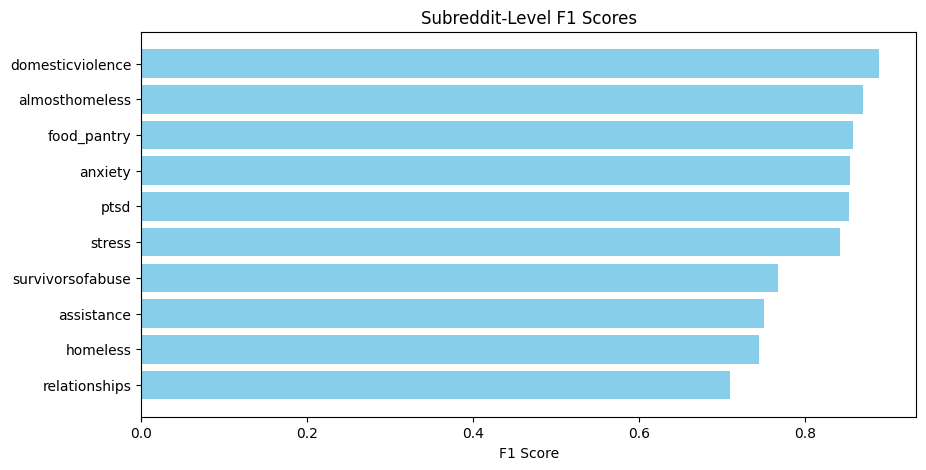

In [86]:
import matplotlib.pyplot as plt

subs = [x[0] for x in sorted_f1]
f1s = [x[1] for x in sorted_f1]

plt.figure(figsize=(10,5))
plt.barh(subs, f1s, color='skyblue')
plt.xlabel("F1 Score")
plt.title("Subreddit-Level F1 Scores")
plt.gca().invert_yaxis()
plt.show()

## Similar to what we see in the exploratory plot, where almosthomeless, domestic violence and anxiety has the highest rate of stress posts, likely easier to predict because posts contain clear stress-related keywords or language about mental health and emotional states.
## For low performing subreddits like survivor of abuse and relationships, language is more nuanced: stories might mix stressful and non-stressful content, contain sarcasm, long narratives, or context-dependent phrasing, like survivor and abuse is contrasting words themselves
## As analysed in previous analysis, bert often picks up and place emphasis on strong keywords like abuse, thus fail to recognise context.

#Conclusion
BERT was selected as the best model and achieved an F1 score of 0.81472. The BERT-based stress detection model can scan posts or messages on support platforms to flag content indicative of high stress, especially among young teenagers, since they are more digitally literate and there has been a rise in the number of stressed-out children and youth in Singapore (2021). This approach may enable timely intervention by counselors or mental health professionals. The model can also be used for trend analysis to identify peaks in community stress, for example during COVID-19 or exam periods.

However, while high recall minimizes false negatives, some non-stress posts may be flagged incorrectly (false positives), causing false alarm. The model may misinterpret sarcasm or reflective writing as stress, as it tends to focus more on negative words and neglect context. Additionally, cultural differences in language expression, such as Singlish and short forms, could affect accuracy.

# References

Michl, L. C., McLaughlin, K. A., Shepherd, K., & Nolen-Hoeksema, S. (2013). Rumination as a mechanism linking stressful life events to symptoms of depression and anxiety: Longitudinal evidence in early adolescents and adults. Journal of Abnormal Psychology, 122(2), 339–352. https://doi.org/10.1037/a0031994

‌(2021). Nus.edu.sg. https://medicine.nus.edu.sg/pcm/more-children-and-teens-are-stressed-out/

‌